## Обучение латентной модели ALS (Matrix Factorization)

In [11]:
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, Dataset
from scipy.sparse import csr_matrix
import scipy.sparse as sp
from sklearn.preprocessing import LabelEncoder
import array

import joblib

In [12]:
def stream_combined_data(paths):
    for path in paths:
        with open('dataset/'+path, 'r') as f:
            movieid = None
            for i, line in enumerate(tqdm(f, desc=path)):
                line = line.strip()
                if line.endswith(':'):
                    movieid = line[:-1]
                else:
                    u, r, d = line.split(',')
                    yield (int(movieid), int(u), int(r), d)

paths = ['combined_data_1.txt','combined_data_2.txt','combined_data_3.txt','combined_data_4.txt']

In [13]:
user_encoder = joblib.load('user_encoder.joblib')
n_users = len(user_encoder.classes_)
item_encoder = joblib.load('item_encoder.joblib')
n_items = len(item_encoder.classes_)
X = sp.load_npz('X_matrix.npz')

In [14]:
who_what_rated = pd.read_csv('who_rated_what_2006.txt', header=None, names=['user_id_orig', 'item_id_orig', 'rating'])
who_what_rated['user_id'] = user_encoder.transform(who_what_rated['user_id_orig'])
who_what_rated['item_id'] = item_encoder.transform(who_what_rated['item_id_orig'])
who_what_rated['rating'] = who_what_rated['rating'].astype(bool).astype(np.float32)
who_what_rated.head(3)

,user_id_orig,item_id_orig,rating,user_id,item_id
0,6,16983,0.0,0,16982
1,10,11888,0.0,3,11887
2,10,14584,1.0,3,14583


### Implicit ALS

In [15]:
import implicit

Обучим модель матричной факторизации Implicit Alternating Least Squares. Это латентный подход, при котором итеративно и поочередно обновляются эмбединги пользователя и фильма.

In [16]:
model_als = implicit.als.AlternatingLeastSquares(
    factors=32,
    regularization=0.01, 
    iterations=10,
    calculate_training_loss=True
)

# model_als.fit(X)
# model_als.save('my_als_model.npz')
model_als = implicit.als.AlternatingLeastSquares().load('my_als_model.npz')


In [17]:
user_factors = model_als.user_factors
item_factors = model_als.item_factors

u_idx = who_what_rated['user_id'].values
i_idx = who_what_rated['item_id'].values

who_what_rated['y_pred_als'] = (user_factors[u_idx] * item_factors[i_idx]).sum(axis=1)

In [18]:
who_what_rated['squared_error_als'] = (who_what_rated['rating'] - who_what_rated['y_pred_als'].clip(0,1)) ** 2
rmse = np.sqrt(who_what_rated['squared_error_als'].mean())

print(f"ELSA RMSE: {rmse:.4}")

ELSA RMSE: 0.2699


Посмотрим на предсказания ALS, отсортируем test по величине предсказания.

In [19]:
who_what_rated[['user_id', 'item_id', 'rating', 'y_pred_als']].sort_values('y_pred_als', ascending=False).head(10)

,user_id,item_id,rating,y_pred_als
55206,265129,7623,1.0,1.776597
18619,89492,8392,0.0,1.429722
48983,235399,7623,1.0,1.387643
80810,389254,11606,1.0,1.335522
48551,233046,16356,1.0,1.334404
31276,150094,16921,1.0,1.255134
86365,415202,13727,0.0,1.245071
44652,213967,11021,0.0,1.236241
72886,350357,14998,1.0,1.225692
18581,89347,6036,0.0,1.202577


приятно видеть, что бОльшая часть из топ 10 пар с высоким предсказанием оказалась положительной (rating>0) 

Также посмотрим на кривые ROC и PR

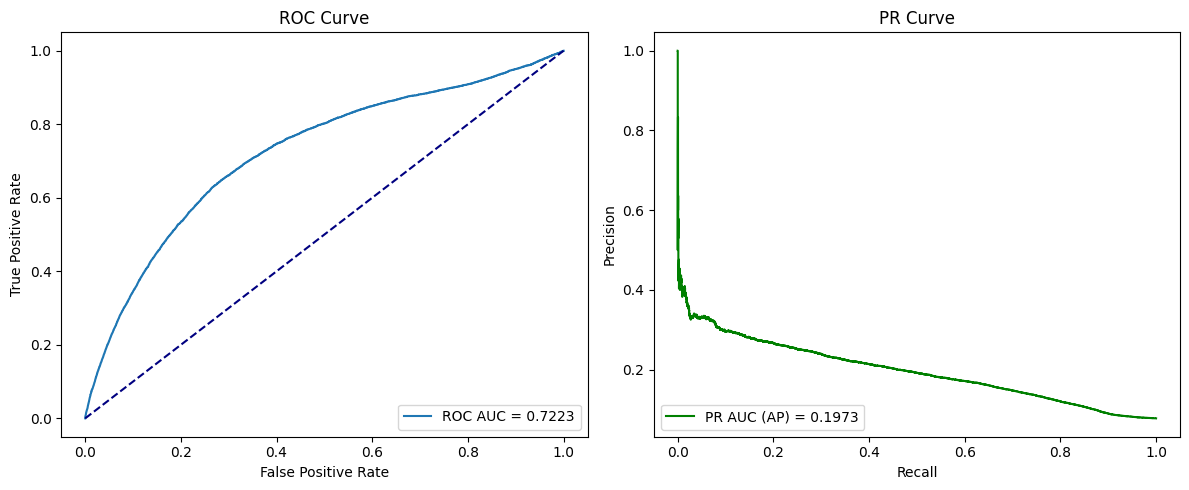

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_true = who_what_rated['rating'].values
y_scores = who_what_rated['y_pred_als'].values

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_true, y_scores)
pr_auc = average_precision_score(y_true, y_scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
ax1.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
ax1.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax1.set_title('ROC Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right")

# PR Curve
ax2.plot(recall, precision, color='green', label=f'PR AUC (AP) = {pr_auc:.4f}')
ax2.set_title('PR Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

RMSE : 0.2699

Не то чтобы очень хорошое качество, но в топ 6 соревнования мы попали.